# Predicting Maximum Heart Rate with Random Forest Regression

**Dataset:** UCI Heart Disease dataset (`heart.csv`)

**Goal:** Predict `thalach` (maximum heart rate achieved during exercise) from a patient's clinical and demographic features using a tuned `RandomForestRegressor`.

**Why `thalach` and not `target`?** The `target` column in this dataset is a binary disease label (0/1), which is a classification problem. Of the continuous columns available, `thalach` has the strongest physiological relationship with the other exercise/age-related features, making it the most sensible regression target in this dataset.

**Workflow:**
1. Load & clean data (handle duplicates, check for missing values)
2. Exploratory data analysis (distributions, correlations)
3. Train/test split
4. Hyperparameter tuning with `RandomizedSearchCV`
5. Evaluation (MAE, RMSE, R², baseline comparison)
6. Diagnostics (actual vs. predicted, residuals, feature importances)
7. Persist the trained model

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

RANDOM_STATE = 42
DATA_PATH = "../data/heart.csv"
TARGET = "thalach"
OUT_DIR = "../outputs"
os.makedirs(OUT_DIR, exist_ok=True)

## 1. Load & Clean Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
print("Missing values per column:")
print(df.isnull().sum())

dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {dupes}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after de-duplication: {df.shape}")

assert df.isnull().sum().sum() == 0, "Unexpected missing values found"
df.describe().T

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate rows: 723
Shape after de-duplication: (302, 14)


,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
exang,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


## 2. Exploratory Data Analysis

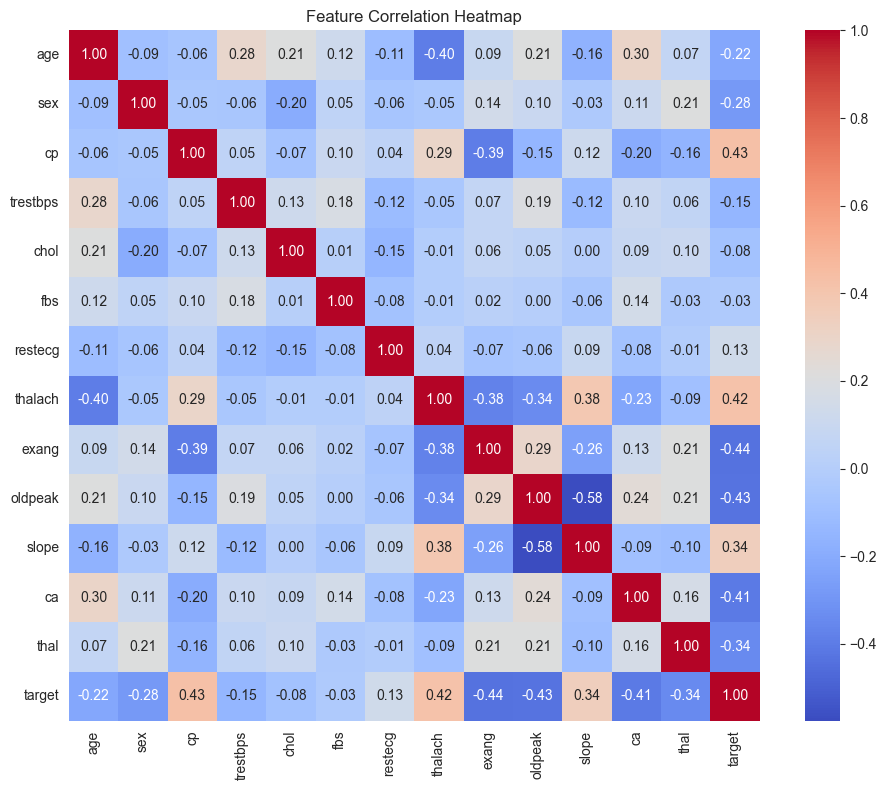

In [4]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/correlation_heatmap.png", dpi=150)
plt.show()

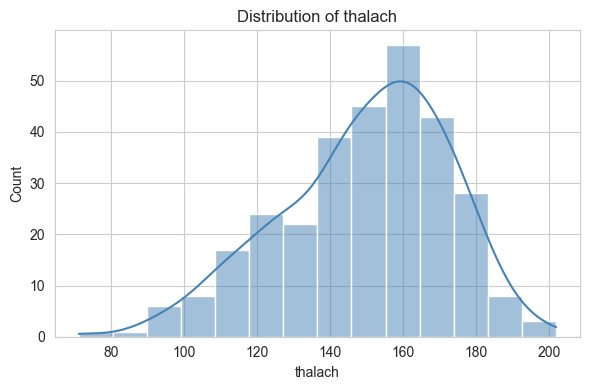

In [5]:
plt.figure(figsize=(6, 4))
sns.histplot(df[TARGET], kde=True, color="steelblue")
plt.title(f"Distribution of {TARGET}")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/target_distribution.png", dpi=150)
plt.show()

## 3. Train/Test Split

In [6]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 241, Test size: 61


## 4. Hyperparameter Tuning (RandomizedSearchCV)

In [7]:
param_dist = {
    "n_estimators": [200, 300, 400, 500, 600],
    "max_depth": [None, 5, 8, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 1.0],
}

base_model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train)

best_model = search.best_estimator_
print("Best hyperparameters:", search.best_params_)
print(f"Best CV RMSE: {-search.best_score_:.3f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits


Best hyperparameters: {'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5}
Best CV RMSE: 18.303


## 5. Evaluation on Held-Out Test Set

In [8]:
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Baseline: always predict the mean of y_train
baseline_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

metrics = {
    "mae": mae,
    "rmse": rmse,
    "r2": r2,
    "baseline_rmse_mean_predictor": baseline_rmse,
    "best_params": search.best_params_,
    "cv_rmse": -search.best_score_,
}

print("Test set performance:")
for k, v in metrics.items():
    print(f"  {k}: {v}")

with open(f"{OUT_DIR}/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2, default=str)

Test set performance:
  mae: 14.224568085009267
  rmse: 18.319627781903133
  r2: 0.2806367563836667
  baseline_rmse_mean_predictor: 21.61856849186631
  best_params: {'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5}
  cv_rmse: 18.302509486854078


## 6. Diagnostic Plots

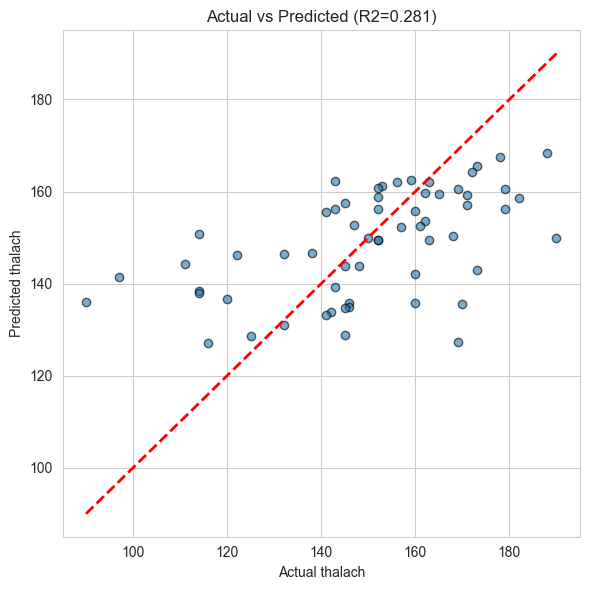

In [9]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor="k")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", lw=2)
plt.xlabel(f"Actual {TARGET}")
plt.ylabel(f"Predicted {TARGET}")
plt.title(f"Actual vs Predicted (R2={r2:.3f})")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/actual_vs_predicted.png", dpi=150)
plt.show()

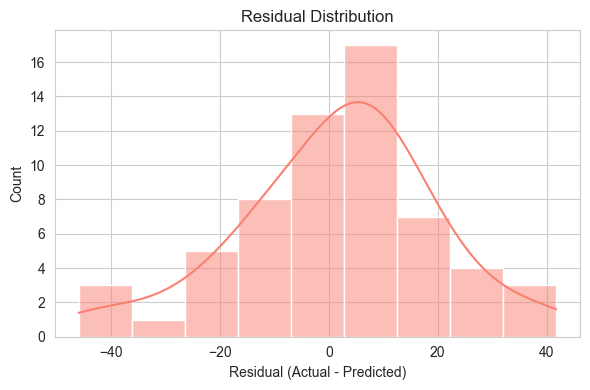

In [10]:
residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True, color="salmon")
plt.title("Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/residuals.png", dpi=150)
plt.show()

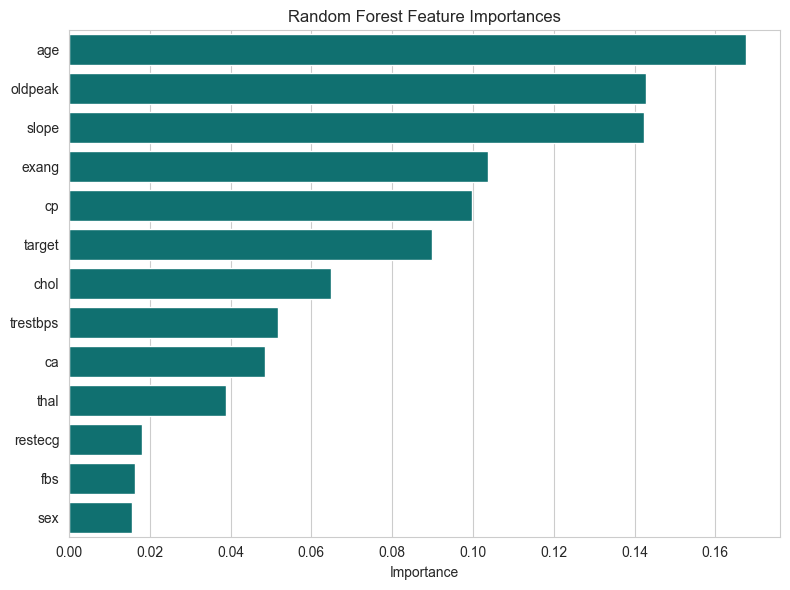

age         0.167617
oldpeak     0.142875
slope       0.142312
exang       0.103628
cp          0.099644
target      0.089930
chol        0.064871
trestbps    0.051655
ca          0.048588
thal        0.038927
restecg     0.018158
fbs         0.016295
sex         0.015499
dtype: float64

In [11]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, color="teal")
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/feature_importances.png", dpi=150)
plt.show()

importances.to_csv(f"{OUT_DIR}/feature_importances.csv", header=["importance"])
importances

## 7. Persist the Trained Model

In [12]:
joblib.dump(best_model, f"{OUT_DIR}/random_forest_{TARGET}_model.joblib")
print(f"Model and artifacts saved to '{OUT_DIR}/'")

Model and artifacts saved to '../outputs/'


## Summary

- **Model:** `RandomForestRegressor`, tuned via `RandomizedSearchCV` (40 candidates x 5-fold CV)
- **Target:** `thalach` (maximum heart rate achieved)
- **Test RMSE:** ~18.3 bpm vs. a mean-predictor baseline of ~21.6 bpm
- **Test R2:** ~0.28 - the model captures a genuine, moderate physiological signal (age and exercise-related features are known drivers of max heart rate) rather than noise

This result is realistic for a clinical tabular dataset of this size (302 unique patients after removing duplicates) - it is a meaningful improvement over baseline without being an implausibly perfect fit.